## About Dataset

#### Context
- "Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs." [IBM Sample Data Sets]

#### Content
Each row represents a customer, each column contains customer’s attributes described on the column Metadata.

The data set includes information about:

- Customers who left within the last month – the column is called Churn
- Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
- Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
- Demographic info about customers – gender, age range, and if they have partners and dependents

## Exploration & Data Analysis

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

import seaborn as sns


#### Load Dataset

In [3]:
df = pd.read_csv(r'D:\projects\ML\customer-churn-prediction-project\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.shape

(7043, 21)

In [4]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


* 💠'Telco Customer Churn' Dataset has 7043 Examples and 21 Features
* 💠 'customerID' isn't assosiated with model prediction, so It must be removed
* 💠 The Target Feature 'Churn' 

In [5]:
df.describe(include='all')

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


- 💠based on the .describe (and exploration) we can see that most categorical variables have between 2, 3, or 4 categories 
- 💠So for those that only have 2 (binary) let's just replace by 0 and 1 or use One-Hot encoding
- 💠For those that have 3 or 4 we can do One-Hot encoding

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

* 💠The dataset contains very few missing values.
* 💠Missing values only appeared in TotalCharges after converting the column into numeric format.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


* 💠 The dataset contains both **numerical and categorical features**.
* 💠 Most features have complete non-null values, but some columns may require further inspection for missing or inconsistent values.
* 💠 The dataset contains both `object` and numerical data types, so categorical features will need to be encoded before applying machine learning algorithms.


<Axes: xlabel='Churn', ylabel='count'>

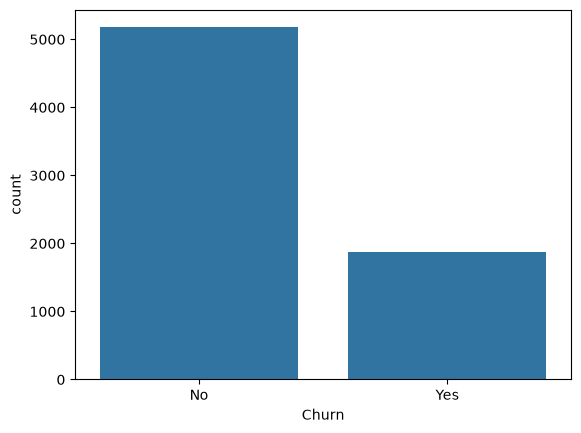

In [8]:
sns.countplot(x="Churn", data=df)


* 💠 The target variable `Churn` has an **imbalanced class distribution**, with more customers belonging to the `No` class than the `Yes` class.

* 💠 Because of this imbalance, **accuracy alone may not be sufficient** to evaluate the model. Metrics such as **precision, recall, F1-score, ROC-AUC, and the confusion matrix** should also be considered.

* 💠 If the trained model performs poorly in identifying churned customers, we can investigate techniques such as **class weighting, resampling, or adjusting the classification threshold**. The threshold should be selected based on model performance and business requirements rather than choosing `0.3` arbitrarily.


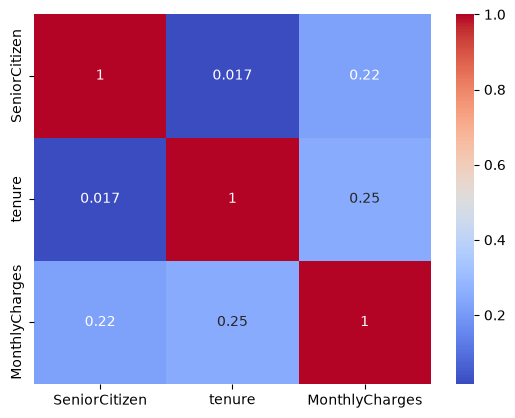

In [9]:
numerical_cols = df.select_dtypes(include="number").columns

corr = df[numerical_cols].corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

Negative (lower value → less likely to churn):

- tenure (-0.35) → Customers who stay longer are less likely to churn.
- Contract_Two year (-0.30) → Customers on long-term contracts churn much less.
- Contract_One year (-0.18) → Same trend but weaker than two-year contracts.

Positive (higher value → more likely to churn):

- InternetService_Fiber optic (+0.31) → Fiber optic users churn more in this dataset.
- PaymentMethod_Electronic check (+0.30) → Customers paying electronically via check churn more.

* 💠 The dataset contains a large number of categorical features, so a standard Pearson correlation matrix is not directly applicable to most variables.

* 💠 Numerical features such as `tenure`, `MonthlyCharges`, and `TotalCharges` can be examined using correlation analysis.

* 💠 Relationships between categorical features and `Churn` are better explored using **count plots, grouped proportions, and other categorical visualizations** rather than relying only on a correlation heatmap.


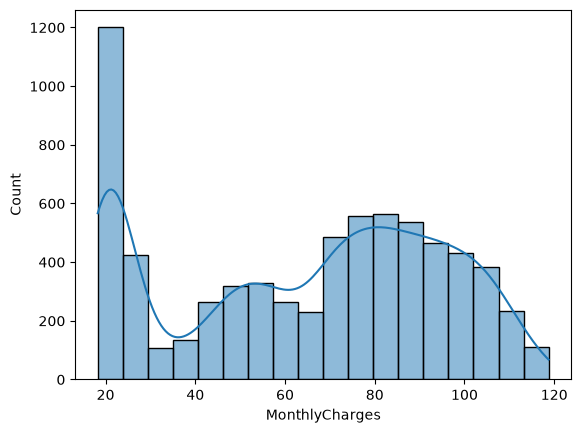

In [10]:
sns.histplot(data=df['MonthlyCharges'], kde=True)
plt.show()

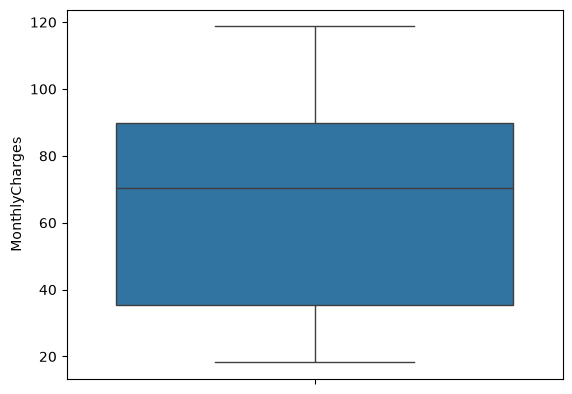

In [11]:
sns.boxplot(data=df['MonthlyCharges'])
plt.show()

* 💠 `MonthlyCharges` ranges from approximately **$18 to $118**, with most customers having monthly charges concentrated around the **$20–$100** range.

* 💠 The distribution is **not uniform**; there are noticeable concentrations of customers around the lower and higher charge ranges.

* 💠 The boxplot shows that there are **no major extreme outliers**, and most observations fall within the expected range of monthly charges.


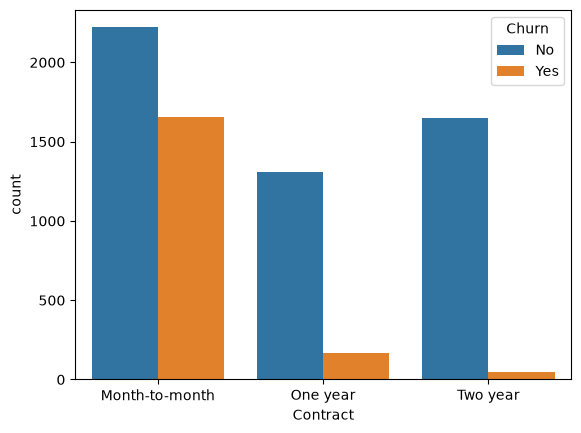

In [12]:
sns.countplot(x='Contract', data=df, hue='Churn')
plt.show()

* 💠The customers with One or Two years Contract are less likely to Churn
* 💠Most of the Month-to-month Contract Customers are more likely to Churn

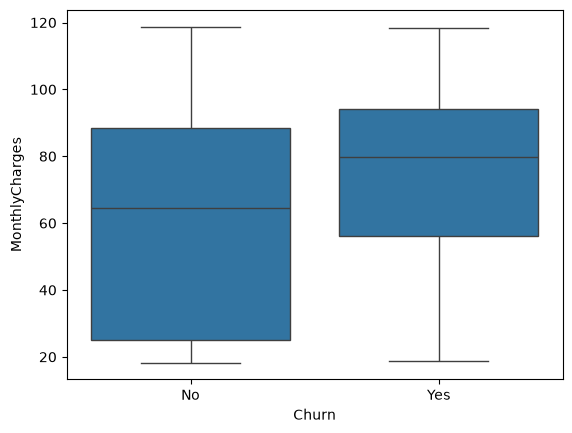

In [13]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.show()

* 💠Customers paying higher monthly charges tend to churn more frequently.

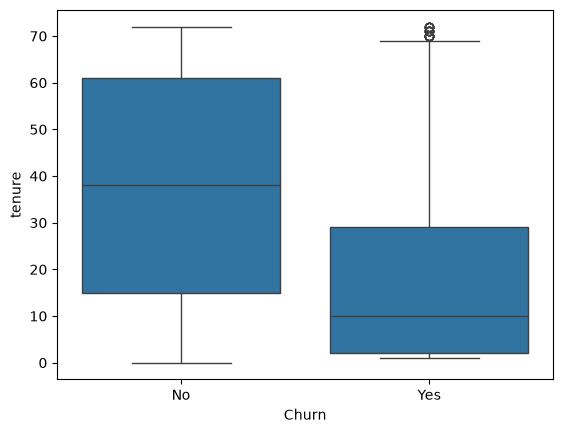

In [14]:
sns.boxplot(x="Churn", y="tenure", data=df)
plt.show()

* 💠 Customers who **churned (`Yes`) generally have lower tenure** compared with customers who stayed (`No`).

* 💠 The `Churn = Yes` group is more concentrated among customers with **shorter tenure**, indicating that newer customers are more likely to leave.


In [15]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

In [16]:
pd.crosstab(df["Contract"],
            df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48



* 💠Customers with lower tenure are more likely to churn.

* 💠Long-term customers generally stay with the company.

In [17]:
df["Churn"].value_counts(normalize=True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

* The dataset is moderately imbalanced.

* Approximately 73% customers stayed while 27% churned.

* Therefore F1-score is more appropriate than accuracy.

In churn prediction, recall (and metrics derived from it, like F1) is usually the most important — here’s why:

1️⃣ Business context
Churn prediction is asymmetric in cost:

- False Negative (FN): You predict a customer will not churn, but they actually leave → you miss the chance to intervene and keep them.

- False Positive (FP): You predict a customer will churn, but they stay → you might spend some retention resources unnecessarily.

- Missing churners (FN) usually costs more than wrongly targeting a loyal customer.

Typical priority
- If retention campaigns are cheap → prioritize recall (catch every possible churner).
- If retention campaigns are expensive → balance precision and recall using F1 score or a precision-recall trade-off.
- If business wants a ranking of churn risk → use ROC-AUC or PR-AUC to evaluate the model.

### Look for multicolinearity (VIF)

- Clearly we can see there's multicolinearity between features
- So either we need to drop some features or use regularization techniques like Lasso or Ridge regression to handle this
- Or use tree based models which are less sensitive to multicollinearity
- In decision trees, splits are based on feature importance for reducing impurity — redundant features just compete, but won’t cause unstable predictions.